# 📊 Titanic Dataset – Mini Exploratory Data Analysis (Task 3)

Data Science with Python Internship – Task 3

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Load Dataset

In [9]:
df = pd.read_csv('titanic.csv')

df.columns = df.columns.str.strip().str.lower()
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

In [10]:
df['age'].fillna(df['age'].mean(), inplace=True)

if 'cabin' in df.columns:
    df.drop(columns=['cabin'], inplace=True)

if 'embarked' in df.columns:
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipython-input-1823701491.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipython-input-1823701491.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
passengerid,0
survived,0
pclass,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0


## Feature Engineering

In [11]:
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child','Teen','YoungAdult','Adult','Senior']

df['agegroup'] = pd.cut(df['age'], bins=bins, labels=labels)
df['familysize'] = df['sibsp'] + df['parch']
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,agegroup,familysize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,YoungAdult,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Adult,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,YoungAdult,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Adult,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Adult,0


## Analysis

In [12]:
df.groupby('agegroup')['survived'].mean()

/tmp/ipython-input-2930341532.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('agegroup')['survived'].mean()


,survived
agegroup,
Child,0.579710
Teen,0.428571
YoungAdult,0.331096
Adult,0.423237
Senior,0.343750


In [13]:
df.groupby('embarked')['survived'].mean()

,survived
embarked,
C,0.553571
Q,0.389610
S,0.339009


In [14]:
df.groupby('familysize')['survived'].mean()

,survived
familysize,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


## Visualizations

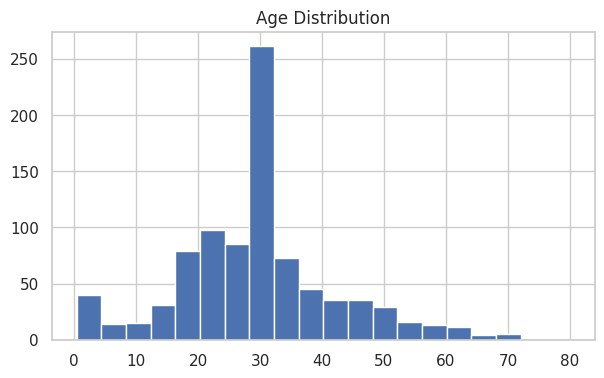

In [15]:
plt.figure(figsize=(7,4))
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.show()

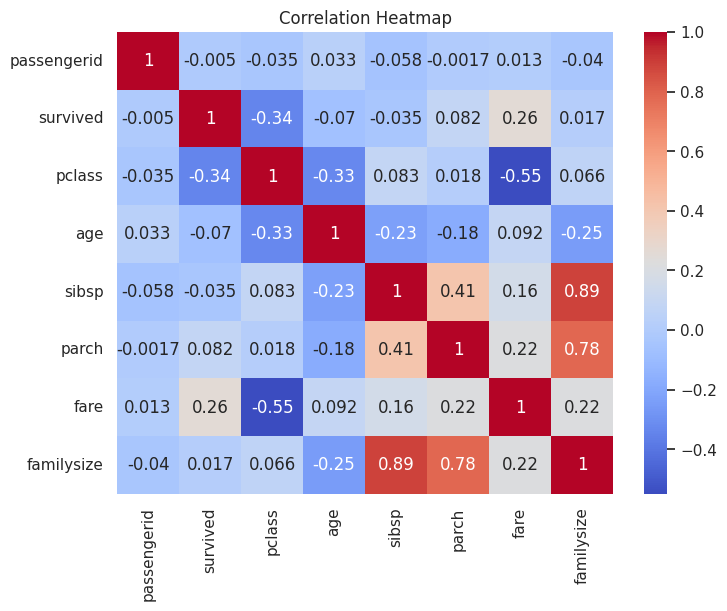

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

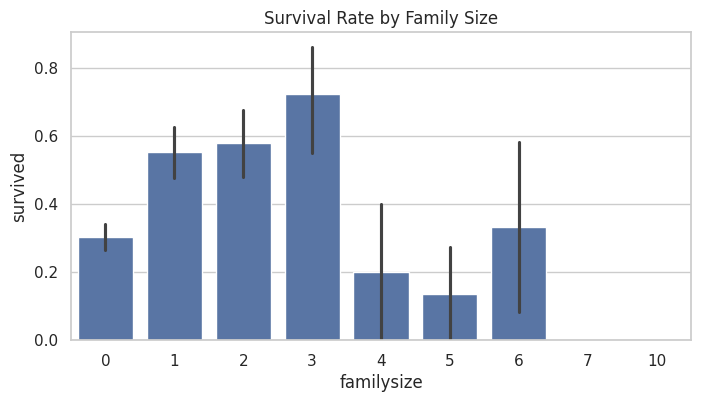

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(x='familysize', y='survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

## Final Insights
- Children survived more
- Small families had better survival
- Embarkation port impacts survival